In [3]:
import cornac
from cornac.data import Reader
from cornac.datasets import movielens
from cornac.data import Dataset, FeatureModality
from cornac.eval_methods import RatioSplit, StratifiedSplit
from cornac.metrics import RMSE, AUC, NDCG, Precision, Recall
from cornac.models import MF, ItemKNN, UserKNN, NMF, BPR, LightGCN, SVD, MostPop, VAECF, NeuMF
import pandas as pd
import numpy as np
import random
import math
from collections import OrderedDict
import seaborn as sns
import matplotlib.pyplot as plt

/Users/tahsinalamgirkheya/anaconda3/envs/cornac/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [10]:
reader = Reader()
rating_data_pd = pd.read_csv(
    "./cornac/data_c/ml-100k/indexed_interactions.csv",
    sep="\t",
    header=None,
    names=["userID", "itemID", "Rating", "Timestamp"],
)
rating_data = rating_data_pd.to_numpy()
rating_data.__len__()
rating_data_pd
df_m = pd.read_csv(
    "./cornac/data_c/ml-100K/u.item",
    sep="|",
    names=[
        "movieID",
        "Name",
        "Date",
        "Video_Date",
        "IMDB_URL",
        "unknown",
        "Action",
        "Adventure",
        "Animation",
        "Children's",
        "Comedy",
        "Crime",
        "Documentary",
        "Drama",
        "Fantasy",
        "Film-Noir",
        "Horror",
        "Musical",
        "Mystery",
        "Romance",
        "Sci-Fi",
        "Thriller",
        "War",
        "Western",
    ],
    header=None,
    encoding="latin-1",
)
print(df_m.shape)
df_m = df_m[
    [
        "movieID",
        "Action",
        "Adventure",
        "Animation",
        "Children's",
        "Comedy",
        "Crime",
        "Documentary",
        "Drama",
        "Fantasy",
        "Film-Noir",
        "Horror",
        "Musical",
        "Mystery",
        "Romance",
        "Sci-Fi",
        "Thriller",
        "War",
        "Western",
    ]
]

df_movies_mapped = pd.read_csv(
    "./cornac/data_c/ml-100K/i_id_mapping.csv",
    sep="\t",
    names=["movieID", "itemID"],
    header=None,
    encoding="latin-1",
)
movies = pd.merge(df_m, df_movies_mapped, how="inner", on="movieID")
movies

(1682, 24)


,movieID,Action,Adventure,Animation,Children's,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western,itemID
0,1,0,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,24
1,2,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,147
2,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,233
3,4,1,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,47
4,5,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,1,0,0,75
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1344,1592,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1305
1345,1597,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1324
1346,1598,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,1319
1347,1615,1,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1341


In [11]:
movies = movies.drop(columns=["movieID"])
movies = movies.sort_values(by="itemID")

In [12]:

unique_genres = [
    "Action",
    "Thriller",
    "Romance",
    "Western",
    "Children's",
    "Mystery",
    "Fantasy",
    "Film-Noir",
    "Documentary",
    "Comedy",
    "Adventure",
    "Sci-Fi",
    "Horror",
    "Crime",
    "Musical",
    "War",
    "Animation",
    "Drama",
]
genre = movies[unique_genres]
item_features_numpy = genre.to_numpy()

users = pd.read_csv("./cornac/data_c/ml-100k/u_id_mapping.csv", sep="\t")

users = users.sort_values(by="userID")

users = users.drop(columns=users.columns[0])
gender_map = {"M": 0, "F": 1}
users["Gender"] = users["Gender"].map(gender_map)
user_features_numpy = users.to_numpy()
users
def create_genre_column(r):
    all_genres = [g for g in unique_genres if r[g] == 1]
    return "|".join(all_genres)


movies["genres"] = movies.apply(create_genre_column, axis=1)
movies

,Action,Adventure,Animation,Children's,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western,itemID,genres
240,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,Comedy
300,0,0,0,0,0,1,0,0,0,1,0,0,1,0,0,1,0,0,1,Thriller|Mystery|Film-Noir|Crime
375,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,2,Children's|Comedy
50,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,1,1,3,Romance|Western|War|Drama
344,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,4,Crime|Drama
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1248,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1344,Drama
1192,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1345,Comedy
1176,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1346,Drama
1261,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1347,Drama


In [13]:
dataset = rating_data
unique_genres.__len__()

18

In [14]:
rec_50 = cornac.metrics.Recall(k=50)
ndcg_50 = cornac.metrics.NDCG(k=50)
auc = cornac.metrics.AUC()
rmse = cornac.metrics.RMSE()
prec = cornac.metrics.Precision(k=50)
hr = cornac.metrics.HitRatio(k=50)
mrr = cornac.metrics.MRR()
map = cornac.metrics.MAP()
ratio_split = StratifiedSplit(
    data=dataset,
    test_size=0.2,
    rating_threshold=0,
    val_size=0.1,
    seed=123,
    verbose=True,
    chrono=True,
    user_features=user_features_numpy[:, 0],
    item_features=item_features_numpy,
    exclude_unknowns=False,
)
models = []
model_1 = UserKNN(k=20, seed=123, verbose=True)
model_2 = ItemKNN(k=20, seed=123, verbose=True)
model_3 = MF(
            k=20,
            seed=123,
            name=f"a={0} mf",
            backend="pytorch",
            verbose=True,
            optimizer="adam",batch_size=256,
            alpha=0,
            learning_rate=0.001,
            top_k=50, max_iter=20,
            # early_stopping=True
        )
model_4 = VAECF(k=32,
        autoencoder_structure=[60,40],
        act_fn="relu",
        likelihood="bern",
        n_epochs=50,
        batch_size=128,
        learning_rate=0.0005,
        alpha=0,
        top_k=50,
        beta=1,
        name=f"a={0} vae",
        seed=123,
        verbose=True,
        # early_stopping=True)
)
model_5 = NeuMF(num_factors=8, layers=[32,16,8], act_fn="sigmoid", num_epochs=59, batch_size=256, num_neg=3, backend="pytorch", lr=0.001, alp=0, top_k=50, name=str(0)+ "neumf", seed = 123) 

    
# model_5 = NeuMF(num_factors=8, layers=[32,16,8], act_fn="relu", num_epochs=64, batch_size=256, num_neg=3, backend="pytorch", lr=0.001, alp=0, top_k=50, name=str(0)+ "neumf")
# models.append(model_5)

models.append(model_1)
models.append(model_2)
models.append(model_3)
models.append(model_4)
models.append(model_5)

   
cornac.Experiment(
    ratio_split, models=models, metrics=[rec_50, ndcg_50, auc, rmse, prec, hr, mrr, map]
).run()

rating_threshold = 0.0
exclude_unknowns = False
::::::::
OrderedDict()
OrderedDict()
::::::::
---
Training data:
(array([  0,   0,   0, ..., 942, 942, 942]), array([  0,   1,   2, ..., 880, 632, 261]), array([4., 4., 4., ..., 1., 5., 4.]))
Number of users = 943
Number of items = 1348
Number of ratings = 68674
Max rating = 5.0
Min rating = 1.0
Global mean = 3.6
Global mean Imolicit= 1.0
::::::::
OrderedDict([(101, 0), (845, 1), (705, 2), (20, 3), (635, 4), (593, 5), (153, 6), (37, 7), (915, 8), (522, 9), (810, 10), (18, 11), (34, 12), (809, 13), (239, 14), (749, 15), (889, 16), (928, 17), (542, 18), (501, 19), (342, 20), (175, 21), (116, 22), (144, 23), (618, 24), (118, 25), (860, 26), (335, 27), (263, 28), (825, 29), (405, 30), (942, 31), (867, 32), (286, 33), (393, 34), (224, 35), (146, 36), (792, 37), (416, 38), (652, 39), (147, 40), (368, 41), (773, 42), (727, 43), (194, 44), (246, 45), (75, 46), (446, 47), (76, 48), (461, 49), (793, 50), (912, 51), (110, 52), (504, 53), (84, 54), (

100%|██████████| 943/943 [00:00<00:00, 50983.90it/s]



[UserKNN] Evaluation started!


Ranking: 100%|██████████| 943/943 [00:02<00:00, 341.34it/s]



[ItemKNN] Training started!


...


[0neumf] Training started!


100%|██████████| 59/59 [01:20<00:00,  1.36s/it, loss=0.258]


[0.6489594578742981, 0.6479648351669312, 0.6469743847846985, 0.6459888219833374, 0.6450058817863464, 0.6440268754959106, 0.6430492401123047, 0.6420727968215942, 0.641097903251648, 0.6401240229606628, 0.6391515731811523, 0.6381789445877075, 0.6372076869010925, 0.6362375617027283, 0.6352675557136536, 0.6342971920967102, 0.6333296298980713, 0.6323606371879578, 0.6313905119895935, 0.63042151927948, 0.6294558644294739, 0.6284878253936768, 0.6275197267532349, 0.6265520453453064, 0.625590980052948, 0.6246118545532227, 0.6236510872840881, 0.6226905584335327, 0.621721625328064, 0.6207536458969116, 0.6198002696037292, 0.6188448071479797, 0.6178814172744751, 0.6169224977493286, 0.6159723401069641, 0.6150264739990234, 0.614061713218689, 0.6131094694137573, 0.6121792197227478, 0.6112332344055176, 0.6103022694587708, 0.609360933303833, 0.6084285378456116, 0.6075000762939453, 0.6065642833709717, 0.6056472063064575, 0.6047459840774536, 0.6038318276405334, 0.6029093861579895, 0.6020335555076599, 0.6011

Ranking: 100%|██████████| 943/943 [00:00<00:00, 1313.08it/s]


VALIDATION:
...
        |   RMSE |    AUC | HitRatio@50 |    MAP |    MRR | NDCG@50 | Precision@50 | Recall@50 | Time (s)
------- + ------ + ------ + ----------- + ------ + ------ + ------- + ------------ + --------- + --------
UserKNN | 0.9898 | 0.5806 |      0.3425 | 0.0168 | 0.0261 |  0.0247 |       0.0102 |    0.0553 |   3.1010
ItemKNN | 1.0549 | 0.5430 |      0.3521 | 0.0165 | 0.0418 |  0.0272 |       0.0117 |    0.0481 |   4.8909
a=0 mf  | 0.9421 | 0.5714 |      0.5249 | 0.0320 | 0.1091 |  0.0667 |       0.0223 |    0.1112 |   0.4926
a=0 vae | 2.6818 | 0.7789 |      0.7678 | 0.0602 | 0.1722 |  0.1303 |       0.0397 |    0.2351 |   1.9240
0neumf  | 2.6818 | 0.8496 |      0.8865 | 0.0899 | 0.2366 |  0.1904 |       0.0540 |    0.3461 |   1.3403

TEST:
...
        |   RMSE |    AUC | HitRatio@50 |    MAP |    MRR | NDCG@50 | Precision@50 | Recall@50 | Train (s) | Test (s)
------- + ------ + ------ + ----------- + ------ + ------ + ------- + ------------ + --------- + --------- + ---

In [15]:
user_ids = users.to_numpy()[:, 1]
item_ids = movies.to_numpy()[:, 2]
item_ids.__len__()
# get the top_k ratings for all users:
top_k = 50
reco_matrix = np.zeros((len(models)+1, len(user_ids), top_k), dtype=int)
reco_matrix_mapped_items = np.zeros(
    (len(models), len(user_ids), len(item_ids)), dtype=int
)
reco_matrix_mapped_scores = np.zeros(
    (len(models), len(user_ids), len(item_ids)), dtype=float
)
reco_matrix_all = np.zeros((len(models)+1, len(user_ids), len(item_ids)), dtype=int)


for u in user_ids:
    for i in range(len(models)):
        reco_items = models[i].recommend(u)
        items_mapped, mapped_scores = models[i].rank(
            user_idx=u, item_indices=list(item_ids)
        )
        reco_matrix_mapped_items[i][u] = items_mapped
        reco_matrix_mapped_scores[i][u] = mapped_scores
        reco_matrix_all[i][u] = reco_items
        reco_matrix[i][u] = reco_items[:top_k]

        # print(reco_matrix[0][3])

In [16]:
####Import Metrics####
from cornac.mymetrics.GenrePrecision import GenrePrecision
from cornac.mymetrics.GenreMapEdited import GenreMapEdited
from cornac.mymetrics.GenreMRR import GenreMRR
from cornac.mymetrics.GenreNDCG import GenreNDCG
from cornac.mymetrics.GenreRecall import GenreRecall
from cornac.mymetrics.GenreRPrecision import GenreRPrecision

top_k = 50
###intialize them
gp = GenrePrecision(users, unique_genres, top_k)
gr = GenreRecall(users, unique_genres, top_k)
gm = GenreMapEdited(users, unique_genres, top_k)
gndcg = GenreNDCG(users, unique_genres, top_k)
gmrr = GenreMRR(users, unique_genres, top_k)

In [17]:
# for r-precision we wanna take the max of the proportiion of total genre in the movie dataset using ranks
movies_df = movies[unique_genres].div(movies[unique_genres].sum(axis=1), axis=0)
movies_df = movies_df[unique_genres].sum()
new_top_k = math.floor(movies_df.max())


# get the top_k ratings for all users:
reco_matrix_top_r = np.zeros((len(models), len(user_ids), new_top_k), dtype=int)

for u in range(len(user_ids)):
    for i in range(len(models)):
        # reco_items, all_scores = models[i].rank(user_idx=user_ids[i], item_indices=list(item_ids))
        reco_matrix_top_r[i][u] = reco_matrix_all[i][u][:new_top_k]


grp = GenreRPrecision(users, unique_genres, top_k)
# MF_grp = grp.compute(reco_matrix_top_r, movies_df, movies)

In [18]:
####IR Metrics####
model_gps = []
model_grs = []
model_gms = []
model_gdcgs = []
model_gmrrs = []

for i in range(len(models)):
    ####Precision####
    model_gps.append(gp.compute(reco_matrix[i], movies))
    ####Recall####
    model_grs.append(gr.compute(reco_matrix[i], movies))
    ####MAP Mean Average Precision####
    model_gms.append(gm.compute(reco_matrix[i], movies))
    ####DCG####
    model_gdcgs.append(gndcg.compute(reco_matrix[i], movies))
    ####MRR####
    model_gmrrs.append(gmrr.compute(reco_matrix[i], movies))



In [19]:
# ####IR Metrics####
# ####Rprecision####
model_grps = []
for i in range(len(models)):
    model_grps.append(grp.compute(reco_matrix_top_r[i], movies_df, movies))
# model_grp = grp.compute(reco_matrix_top_r[0], movies_df, movies)
# model_grp_2 = grp.compute(reco_matrix_top_r[1], movies_df, movies)
# model_grp_3 = grp.compute(reco_matrix_top_r[2], movies_df, movies)
# model_grp_4 = grp.compute(reco_matrix_top_r[3], movies_df, movies)
# model_grp_5 = grp.compute(reco_matrix_top_r[4], movies_df, movies)

          Action  Thriller   Romance   Western  Children's   Mystery  Fantasy  \
Gender                                                                          
0       0.040212  0.092668  0.080516  0.000168    0.002974  0.011491      0.0   
1       0.038650  0.092238  0.083770  0.000263    0.003771  0.011563      0.0   

        Film-Noir  Documentary    Comedy  Adventure    Sci-Fi    Horror  \
Gender                                                                    
0        0.000762     0.041552  0.152715   0.014889  0.023551  0.002714   
1        0.000935     0.040293  0.153156   0.014372  0.021000  0.003275   

           Crime   Musical       War  Animation     Drama  
Gender                                                     
0       0.041116  0.000851  0.037107   0.086524  0.382513  
1       0.038294  0.001384  0.034535   0.086466  0.382377  
[[4.02120542e-02 9.26678752e-02 8.05156837e-02 1.68388825e-04
  2.97442451e-03 1.14905074e-02 0.00000000e+00 7.62146713e-04
  4.155223

In [20]:
from operator import itemgetter

# unique_genres
indices = [0,  2, 11, 17]
compare_genres = itemgetter(*indices)(unique_genres)
# compare_genres = unique_genres
# indices = range(18)
# alpha_values = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.99999999999]

list(compare_genres)

['Action', 'Romance', 'Sci-Fi', 'Drama']

In [21]:
gp_sum = [sum(abs(model_gps[i])) for i in range(len(models))]
gr_sum = [sum(abs(model_grs[i])) for i in range(len(models))]
gm_sum = [sum(abs(model_gms[i])) for i in range(len(models))]
gdcg_sum = [sum(abs(model_gdcgs[i])) for i in range(len(models))]
gmrr_sum = [sum(abs(model_gmrrs[i])) for i in range(len(models))]
grp_sum = [sum(abs(model_grps[i])) for i in range(len(models))]


['UserKNN', 'ItemKNN', 'MF', 'VAECF', 'NeuMF']
[<BarContainer object of 4 artists>, <BarContainer object of 4 artists>, <BarContainer object of 4 artists>, <BarContainer object of 4 artists>, <BarContainer object of 4 artists>]


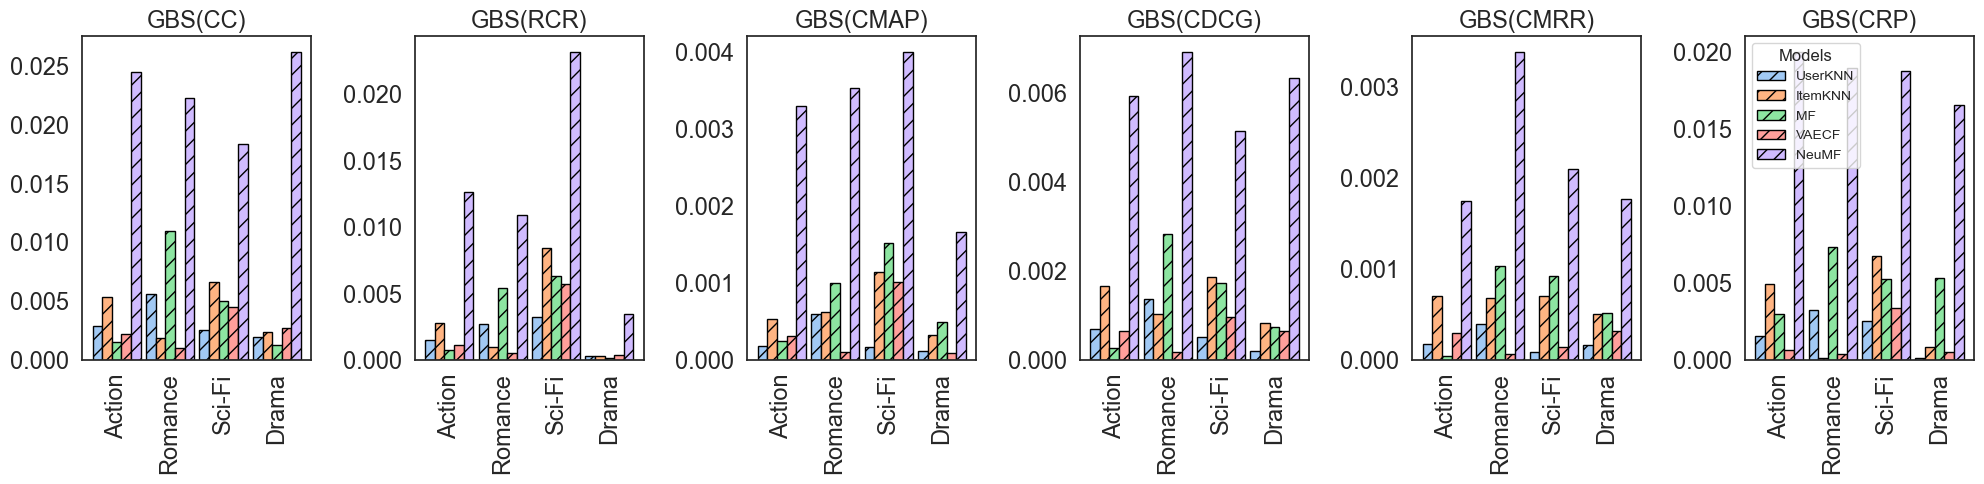

In [22]:
import matplotlib.pyplot as plt
import numpy as np
sns.set(style="white")
pastel_colors = sns.color_palette("pastel")

# alpha_values =[0,0.1,0.2,0.3,0.4,0.5,0.6]
matrices = [
    model_gps[0][indices],
    model_grs[0][indices],
    model_gms[0][indices],
    model_gdcgs[0][indices],
    model_gmrrs[0][indices],
    model_grps[0][indices],
]
matrices_2 = [
    model_gps[1][indices],
    model_grs[1][indices],
    model_gms[1][indices],
    model_gdcgs[1][indices],
    model_gmrrs[1][indices],
    model_grps[1][indices],
]
matrices_3 = [
    model_gps[2][indices],
    model_grs[2][indices],
    model_gms[2][indices],
    model_gdcgs[2][indices],
    model_gmrrs[2][indices],
    model_grps[2][indices],
]
matrices_4 = [
    model_gps[3][indices],
    model_grs[3][indices],
    model_gms[3][indices],
    model_gdcgs[3][indices],
    model_gmrrs[3][indices],
    model_grps[3][indices],
]
matrices_5 = [
    model_gps[4][indices],
    model_grs[4][indices],
    model_gms[4][indices],
    model_gdcgs[4][indices],
    model_gmrrs[4][indices],
    model_grps[4][indices],
]

labels = compare_genres
titles = [
    "GBS(CC)",
    "GBS(RCR)",
    "GBS(CMAP)",
    "GBS(CDCG)",
    "GBS(CMRR)",
    "GBS(CRP)",
]


fig, axs = plt.subplots(1,6, figsize=(20, 5))
axs = axs.flatten()
x = np.arange(len(compare_genres))  # the label locations
bar_width = 0.18  # the width of the bars
bar_spacing =0.0
# rects1 = ax.bar(x - 3*bar_width/2, gender_genre_weights_topk_recom.iloc[0]*100, bar_width, label='Female (Top 50)', color="#bca0dc")
hatches = ['//', '\\\\', '||', '--', '++']

for i in range(len(titles)):
    axs[i].bar(
        x - 2 * (bar_width + bar_spacing), abs(matrices[i]), bar_width, color=pastel_colors[0],
        edgecolor='black', hatch=hatches[0], label="UserKNN"
    )
    axs[i].bar(
        x - 1 * (bar_width + bar_spacing), abs(matrices_2[i]), bar_width, color=pastel_colors[1],
        edgecolor='black', hatch=hatches[0], label="ItemKNN"
    )
    axs[i].bar(
        x + 0 * (bar_width + bar_spacing), abs(matrices_3[i]), bar_width, color=pastel_colors[2],
        edgecolor='black', hatch=hatches[0], label="MF"
    )
    axs[i].bar(
        x + 1 * (bar_width + bar_spacing), abs(matrices_4[i]), bar_width, color=pastel_colors[3],
        edgecolor='black', hatch=hatches[0], label="VAECF"
    )
    axs[i].bar(
        x + 2 * (bar_width + bar_spacing), abs(matrices_5[i]), bar_width, color=pastel_colors[4],
        edgecolor='black', hatch=hatches[0], label="NeuMF"
    )
 
    
    axs[i].set_xticks(x)
    axs[i].set_xticklabels(compare_genres, rotation=90, fontsize=17)
    # axs[i].set_yticklabels( fontsize=17)
    axs[i].tick_params(axis="y", labelsize =17)
    
    # axs[i].set_y
    axs[i].set_title(titles[i], fontsize =17)
    # axs[i].set_xlabel("Genres")
    # axs[i].set_ylabel("Values")
    axs[i].tick_params(axis="x", rotation=90)
    


handles, labels = axs[0].get_legend_handles_labels()
print(labels)
print(handles)


plt.legend(handles, labels, loc="upper left", fontsize="small", title="Models")
# Adjust layout
plt.tight_layout()
plt.savefig("all_models_plain.pdf", format="pdf")

plt.show()

In [25]:
ml100k_dataset = [matrices,matrices_2,matrices_3,matrices_4,matrices_5]

In [4]:
yelp_dataset = [[np.array([-0.00156712,  0.00055592,  0.00052878, -0.00027414]),
  np.array([-0.00100616,  0.0004162 ,  0.00108612, -0.00010967]),
  np.array([-5.50794160e-04, -5.98549115e-06,  2.44820711e-05, -1.62735764e-05]),
  np.array([-6.64189693e-04,  5.68491492e-05,  1.13618072e-04, -4.95461145e-05]),
  np.array([-4.54476414e-04, -2.62780288e-05,  2.49411191e-05, -3.70757164e-06]),
  np.array([-0.00133214,  0.0004787 ,  0.00019217, -0.00048771])],
 [np.array([-0.00385812,  0.00436408,  0.00261333, -0.00358618]),
  np.array([-0.00247709,  0.00326723,  0.00536776, -0.00143466]),
  np.array([-0.00066944,  0.00046471,  0.00071573, -0.00031911]),
  np.array([-0.0015569 ,  0.00096918,  0.00071816, -0.00102287]),
  np.array([-0.00095674,  0.00024312,  0.00027029, -0.00044144]),
  np.array([-0.00241846,  0.00445874,  0.00278678, -0.00262425])],
 [np.array([-0.0038676 ,  0.00643957,  0.00299338, -0.00619502]),
  np.array([-0.00248317,  0.00482107,  0.00614838, -0.00247834]),
  np.array([-0.0002186 ,  0.00062414,  0.00227256, -0.00073245]),
  np.array([-0.00086291,  0.00142396,  0.00137575, -0.00186547]),
  np.array([-0.00018339,  0.00032012,  0.00095121, -0.00085695]),
  np.array([-0.00317718,  0.00599657,  0.00437935, -0.00681786])],
 [np.array([ 2.74581991e-04,  8.71518419e-04,  6.28930818e-05, -7.18011088e-04]),
  np.array([ 0.00017629,  0.00065247,  0.00012918, -0.00028724]),
  np.array([ 4.05077117e-06,  4.44646477e-05, -8.98419175e-06, -5.25353937e-05]),
  np.array([ 4.35939841e-05,  1.57210698e-04,  4.90940931e-06, -1.81751790e-04]),
  np.array([ 2.07610246e-06,  1.97550099e-05, -5.36147162e-06, -7.22334714e-05]),
  np.array([ 3.35352417e-04, -2.28456023e-05,  7.87693899e-05,  3.45432072e-04])],
 [np.array([-0.01753799,  0.0065905 ,  0.00760006,  0.0014778 ]),
  np.array([-0.01126017,  0.00493406,  0.01561046,  0.0005912 ]),
  np.array([-0.00239883,  0.00166945,  0.00440227,  0.00097577]),
  np.array([-0.00443248,  0.00195941,  0.00222244,  0.00089704]),
  np.array([-0.00142186,  0.00085539,  0.00096256,  0.00068927]),
  np.array([-0.01706546,  0.00606464,  0.00896292, -0.00014307])]]

ml1m_dataset = [[np.array([ 0.00071548, -0.00132818,  0.00140097,  0.00324785]),
  np.array([ 0.00015928, -0.00031473,  0.00057756,  0.00016894]),
  np.array([ 6.74308702e-05, -4.62420718e-05,  9.96173340e-05,  3.77455161e-03]),
  np.array([ 0.00011891, -0.00027135,  0.00029087,  0.0007535 ]),
  np.array([ 5.58240948e-06, -4.70544165e-05,  5.38757345e-05,  1.25233685e-04]),
  np.array([-0.0006845 , -0.00064409,  0.00014741,  0.0020005 ])],
 [np.array([ 0.01442696, -0.00948018,  0.00554175, -0.01406182]),
  np.array([ 0.0032117 , -0.00224649,  0.00228463, -0.00073145]),
  np.array([ 0.00295537, -0.00174484,  0.00077181, -0.00496816]),
  np.array([ 0.00362125, -0.00222853,  0.00141714, -0.00219785]),
  np.array([ 0.0011617 , -0.00059026,  0.00049003,  0.00030923]),
  np.array([ 0.01017943, -0.0070724 ,  0.00527034, -0.0033305 ])],
 [np.array([ 0.03137861, -0.01669909,  0.02342532, -0.02956998]),
  np.array([ 0.00698544, -0.00395713,  0.00965727, -0.00153813]),
  np.array([ 0.01051468, -0.00271176,  0.00563437, -0.01344532]),
  np.array([ 0.00900676, -0.00447996,  0.00668903, -0.00831202]),
  np.array([ 0.00377022, -0.00164131,  0.00279907, -0.00348655]),
  np.array([ 0.02661798, -0.01540788,  0.0217901 , -0.01919324])],
 [np.array([ 0.04569266, -0.01078633,  0.03405844, -0.04926512]),
  np.array([ 0.01017201, -0.002556  ,  0.01404086, -0.0025626 ]),
  np.array([ 0.01536723, -0.0014269 ,  0.00949145, -0.02204548]),
  np.array([ 0.01228373, -0.00286276,  0.00986735, -0.01415788]),
  np.array([ 0.00463416, -0.00100116,  0.00417702, -0.00593836]),
  np.array([ 0.03719413, -0.0082617 ,  0.02906953, -0.03934624])],
 [np.array([ 0.05046439, -0.04899417,  0.03918195, -0.04579498]),
  np.array([ 0.01123428, -0.01160999,  0.01615307, -0.0023821 ]),
  np.array([ 0.0150125 , -0.01421073,  0.01025437, -0.02692515]),
  np.array([ 0.01351383, -0.01318664,  0.01045541, -0.0119328 ]),
  np.array([ 0.00504242, -0.00501127,  0.00386203, -0.00424327]),
  np.array([ 0.03934686, -0.03662611,  0.03238553, -0.0330782 ])]]

In [37]:
def plot_dataset(axs, matrices_list, titles, cg, pastel_colors, xrotation):
    x = np.arange(len(cg))
    bar_width = 0.18
    bar_spacing = 0.0
    hatches = ['//', '\\\\', '||', '--', '++']

    matrices, matrices_2, matrices_3, matrices_4, matrices_5 = matrices_list

    for i in range(len(titles)):
        axs[i].bar(x - 2*(bar_width+bar_spacing), abs(matrices[i]),   bar_width,
                   color=pastel_colors[0], edgecolor='black', label="UserKNN")
        axs[i].bar(x - 1*(bar_width+bar_spacing), abs(matrices_2[i]), bar_width,
                   color=pastel_colors[1], edgecolor='black', label="ItemKNN")
        axs[i].bar(x + 0*(bar_width+bar_spacing), abs(matrices_3[i]), bar_width,
                   color=pastel_colors[2], edgecolor='black',  label="MF")
        axs[i].bar(x + 1*(bar_width+bar_spacing), abs(matrices_4[i]), bar_width,
                   color=pastel_colors[3], edgecolor='black', label="VAECF")
        axs[i].bar(x + 2*(bar_width+bar_spacing), abs(matrices_5[i]), bar_width,
                   color=pastel_colors[4], edgecolor='black',  label="NeuMF")

        axs[i].set_xticks(x)
        axs[i].set_xticklabels(cg, fontsize=11, rotation=xrotation)

        axs[i].tick_params(axis="y", labelsize=15)
        axs[i].set_title(titles[i], fontsize=16)


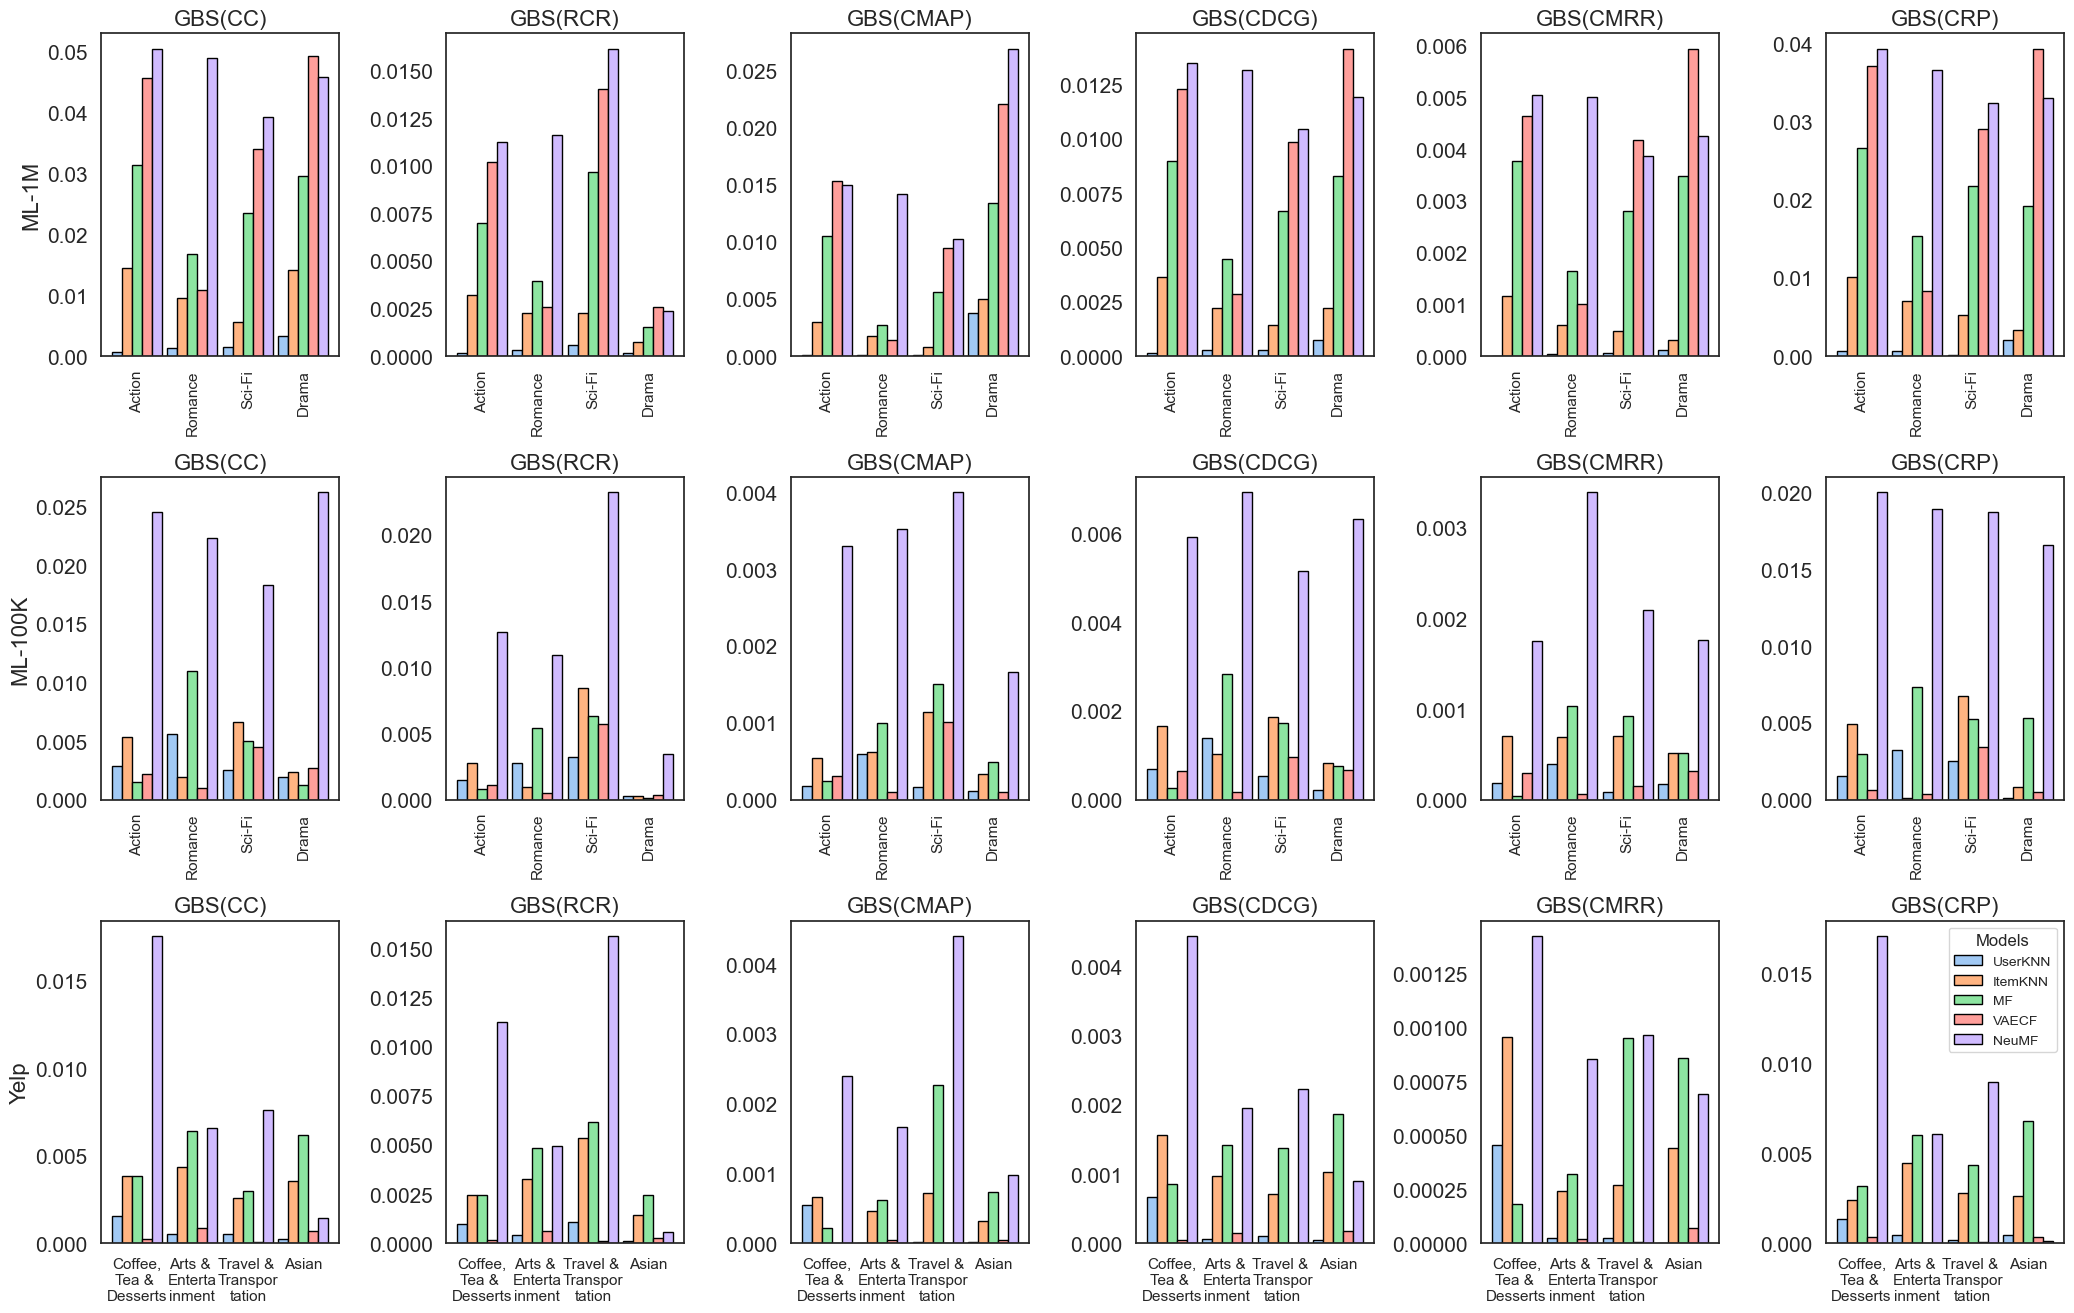

In [38]:
fig, axs = plt.subplots(3, 6, figsize=(22, 14))
cg_movies = ['Action', 'Romance', 'Sci-Fi', 'Drama']

cg_yelp = [
    'Coffee,\nTea & \nDesserts',
    'Arts & \nEnterta\ninment',
    'Travel & \nTranspor\ntation',
    'Asian'
]

plot_dataset(axs[0], ml1m_dataset, titles, cg_movies, pastel_colors, 90)
plot_dataset(axs[1], ml100k_dataset, titles, cg_movies, pastel_colors, 90)
plot_dataset(axs[2], yelp_dataset, titles, cg_yelp, pastel_colors,0)

# Row labels (optional but recommended)
axs[0, 0].set_ylabel("ML-1M", fontsize=16)
axs[1, 0].set_ylabel("ML-100K", fontsize=16)
axs[2, 0].set_ylabel("Yelp", fontsize=16)

handles, labels = axs[0, 0].get_legend_handles_labels()
axs[2, 5].legend(
    handles,
    labels,
    loc="upper right",      # inside bottom-right of the subplot
    fontsize=10,
    title="Models",
    frameon=True
)
# fig.legend(
#     handles,
#     labels,
#     loc="lower right",
#     fontsize=12,
#     title="Models",
#     frameon=True
# )
plt.tight_layout(rect=[0, 0.05, 0.95, 1])
plt.savefig("all_models_3_datasets.pdf", format="pdf")
plt.show()



In [1]:
ml100k_dataset

NameError: name 'ml100k_dataset' is not defined